# Import

In [1]:
#the usual 
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

#rdkit
from rdkit import Chem
from rdkit.Chem import AllChem, Draw, DataStructs, rdFingerprintGenerator, PandasTools
PandasTools.RenderImagesInAllDataFrames(images=True) # when true, it displays the structures in the DF output

#others
from sklearn.metrics import jaccard_score
from matplotlib.colors import LogNorm
from tqdm import tqdm

### Load dataset, curate and move to pickle 

# Load data

,inchi,inchikey,Structure,Salt,NumAtoms
inchi_id,,,,,
1,InChI=1S/C6H4ClNO2/c7-5-1-3-6(4-2-5)8(9)10/h1-4H,CZGCEKJOLUNIFY-UHFFFAOYSA-N,,False,10
2,InChI=1S/C6H6N2O2/c7-5-1-3-6(4-2-5)8(9)10/h1-4...,TYMLOMAKGOJONV-UHFFFAOYSA-N,,False,10
3,"InChI=1S/C6H5NO3/c8-6-3-1-5(2-4-6)7(9)10/h1-4,8H",BTJIUGUIPKRLHP-UHFFFAOYSA-N,,False,10
4,InChI=1S/C6H5ClO2S/c7-5-1-3-6(4-2-5)10(8)9/h1-...,AOQYAMDZQAEDLO-UHFFFAOYSA-N,,False,10
7,InChI=1S/C9H10O2/c1-7(10)8-3-5-9(11-2)6-4-8/h3...,NTPLXRHDUXRPNE-UHFFFAOYSA-N,,False,11
...,...,...,...,...,...
359105,"InChI=1S/O6Si2/c1-7(2)6-8(3,4)5/q-4",NYRJGAMJBNFXOM-UHFFFAOYSA-N,,False,8
359107,"InChI=1S/O7Si2/c1-8(2,3)7-9(4,5)6/q-6",KUDCBYUNCUYIDU-UHFFFAOYSA-N,,False,9
359108,InChI=1S/O7Si3/c1-8(2)6-10(5)7-9(3)4/q-2,MXSSWTMUAUJAKG-UHFFFAOYSA-N,,False,10

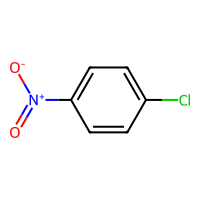
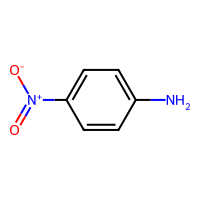
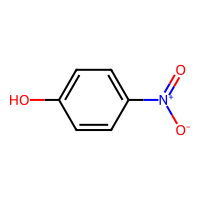
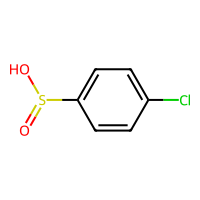
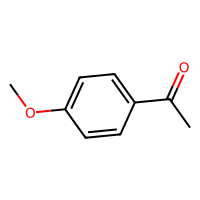
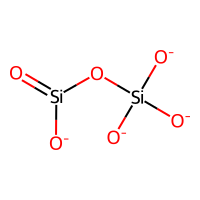
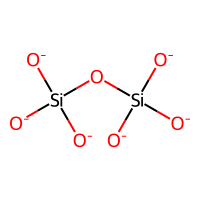
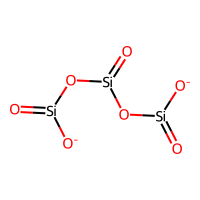
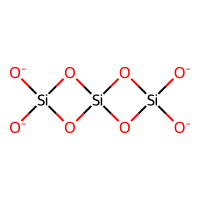
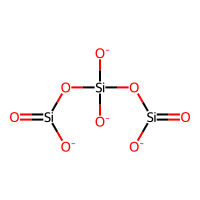

In [2]:
df = pd.read_pickle("./substances.pkl") 
df

# Bit collisions 

In [3]:
# generators 
fp_gen_sparse = rdFingerprintGenerator.GetTopologicalTorsionGenerator()
sizes = [1024, 2048, 4096, 8192, 16384, 32768]
fp_gens_folded = {size: rdFingerprintGenerator.GetTopologicalTorsionGenerator(fpSize=size) for size in sizes}

records = []

# loop over molecules with tqdm progress bar
for mol in tqdm(df['Structure'], desc="Processing molecules"):
    rec = {}
    
    # sparse bits count
    rec["sparse_bits"] = len(fp_gen_sparse.GetSparseFingerprint(mol).GetOnBits())
    
    # folded bits counts
    for size, gen in fp_gens_folded.items():
        rec[f"folded_bits_{size}"] = gen.GetFingerprint(mol).GetNumOnBits()
    records.append(rec)

bit_col_df = pd.DataFrame(records)

# percentages calculation
percent_col = {
    size: f"{(bit_col_df['sparse_bits'] != bit_col_df[f'folded_bits_{size}']).sum() * 100 / len(df):0.1f}" for size in sizes}
percent_col

Processing molecules: 100%|██████████████████████████████████████████████████| 258584/258584 [03:58<00:00, 1084.39it/s]


{1024: '29.0',
 2048: '17.0',
 4096: '11.1',
 8192: '7.8',
 16384: '5.2',
 32768: '4.3'}

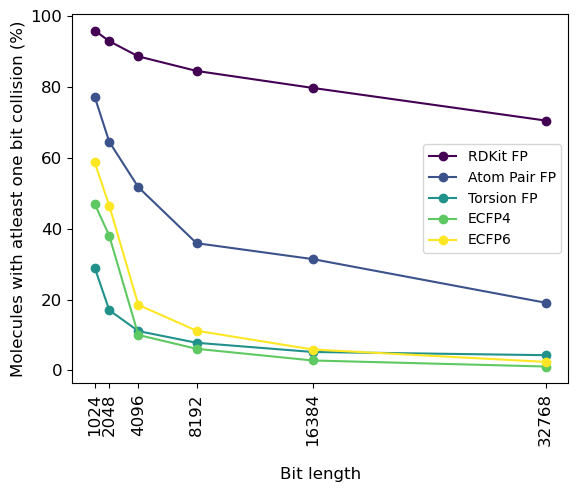

In [34]:
ECFP_4 = {1024: 47.0,
 2048: 38.0,
 4096: 10.0,
 8192: 6.1,
 16384: 2.8,
 32768: 1.1}

ECFP_6 = {1024: 58.7,
 2048: 46.5,
 4096: 18.5,
 8192: 11.2,
 16384: 5.9,
 32768: 2.4}

rdkit_fp = {1024:   95.9  ,
 2048:   92.9  ,
 4096:   88.6  ,
 8192:   84.5  ,
 16384:   79.7  ,
 32768:   70.5  }

atom_pair = {1024:   77.2  ,
 2048:   64.5  ,
 4096:   51.7  ,
 8192:   35.9  ,
 16384:   31.4  ,
 32768:   19.1  }

torsion = {1024:   29.0  ,
 2048:   17.0  ,
 4096:   11.1  ,
 8192:   7.8  ,
 16384:   5.2  ,
 32768:   4.3  }


labels = ["RDKit FP", "Atom Pair FP", "Torsion FP" , "ECFP4" , "ECFP6"]
fingerprints = [rdkit_fp , atom_pair, torsion, ECFP_4 , ECFP_6]
cmap = plt.cm.viridis
colors = cmap(np.linspace(0, 1, len(labels)))

i=0
plt.figure()
for fp in fingerprints:
    plt.plot(fp.keys(), fp.values(), marker='o', label=labels[i], color=colors[i])
    i=i+1

plt.xlabel("Bit length", size=12, labelpad=15)
plt.ylabel('Molecules with atleast one bit collision (%)',size=12)
plt.xticks([1024, 2048, 4096, 8192, 16384, 32768], rotation=90, size=12)
plt.yticks(size=12)
plt.legend()
plt.show()

# Effect on similarity

In [ ]:
### lets see if this works on a small number of molecules before we proceed

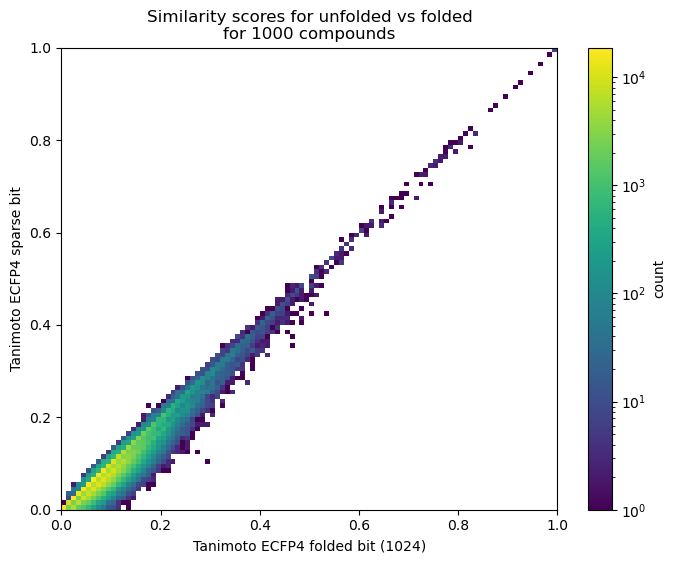

In [40]:
# sample random compounds and select te structures
df_sample = df.sample(n=1000, random_state=42)
mols = df_sample.Structure
n = len(mols)

# fingerprints
ecfp4 = [AllChem.GetMorganGenerator(radius = 2, fpSize=1024).GetFingerprint(m) for m in mols]
sparse_ecfp4 = [AllChem.GetMorganGenerator(radius=2).GetSparseFingerprint(m) for m in mols]

# initialize histogram
counts = np.zeros((100, 100))

# Loop over molecules, compare against all later ones
for i in range(n):
    sims_fold = DataStructs.BulkTanimotoSimilarity(ecfp4[i], ecfp4[i+1:])
    sims_sparse = DataStructs.BulkTanimotoSimilarity(sparse_ecfp4[i], sparse_ecfp4[i+1:])
    
    # update histogram 
    hist, _, _ = np.histogram2d(
        sims_fold, sims_sparse,
        bins=100, range=[[0,1],[0,1]]
    )
    counts += hist

# mask zero-count bins
counts_masked = np.ma.masked_where(counts == 0, counts)

# plot
plt.figure(figsize=(8, 6))

plt.pcolormesh(
    np.linspace(0,1,101),
    np.linspace(0,1,101),
    counts_masked.T,
    cmap="viridis",
    norm=LogNorm(vmin=1, vmax=counts.max())) # log scale is needed

plt.colorbar(label="count")
plt.xlabel("Tanimoto ECFP4 folded bit (1024)")
plt.ylabel("Tanimoto ECFP4 sparse bit")
plt.title(f"Similarity scores for unfolded vs folded\nfor {n} compounds")
plt.show()

### looping over different lengths

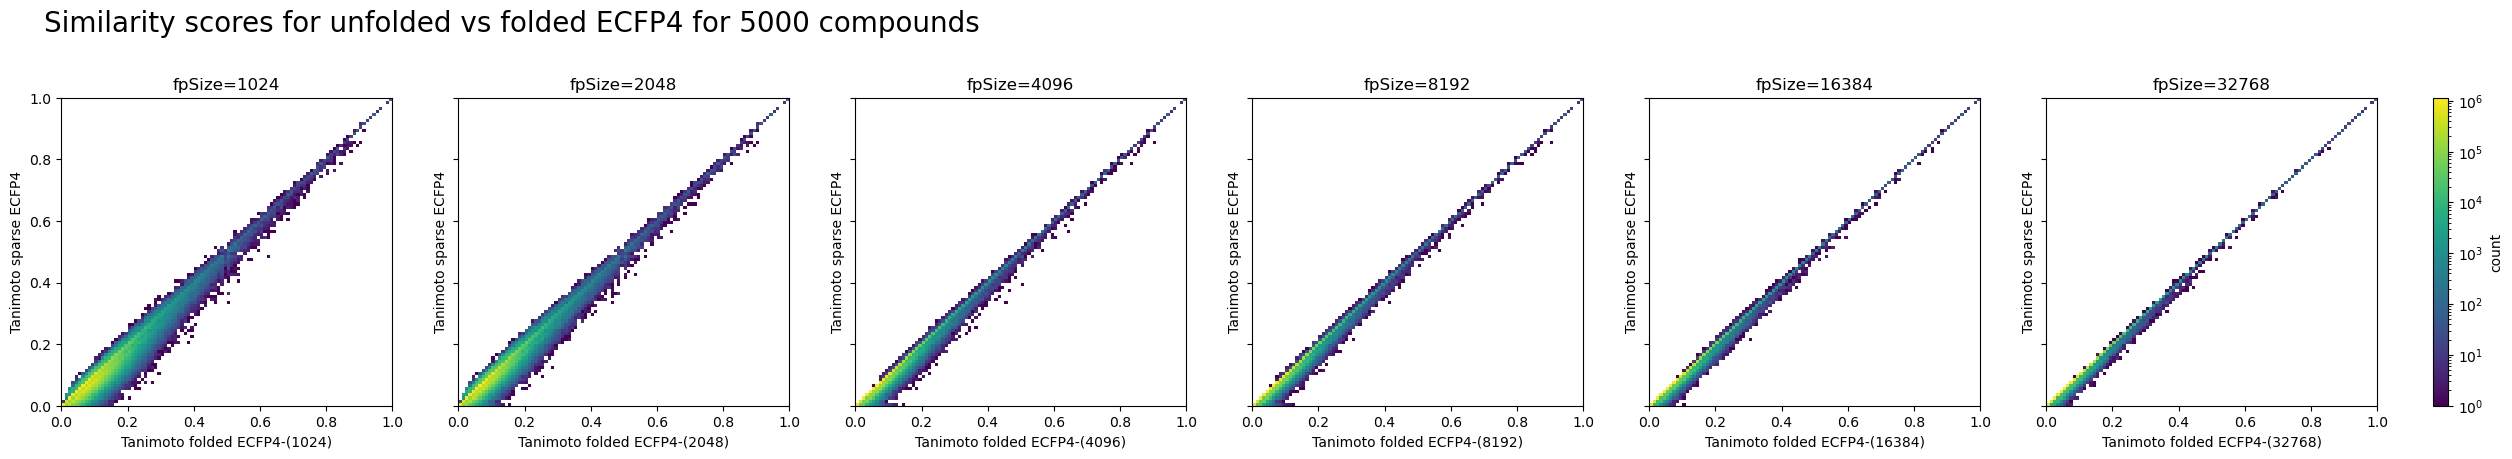

In [65]:
# sample random compounds and select te structures
df_sample = df.sample(n=5000, random_state=42)
mols = df_sample.Structure
n = len(mols)

#sizes
sizes = [1024, 2048, 4096, 8192, 16384, 32768]

# fingerprints 
fingerprints = {size: [AllChem.GetMorganGenerator(radius = 2, fpSize=size).GetFingerprint(m) for m in mols] for size in sizes}
sparse_ecfp4 = [AllChem.GetMorganGenerator(radius=2).GetSparseFingerprint(m) for m in mols]

# subplot grid
fig, axes = plt.subplots(1, len(sizes), figsize=(6*len(sizes), 4), sharex=True, sharey=True)

for ax, size in zip(axes, sizes):
    ecfp = fingerprints[size]
    counts = np.zeros((100, 100))

    # histogram 
    for i in tqdm(range(n), desc=f"Processing fpSize={size}", unit="mol"):
        sims_fold = DataStructs.BulkTanimotoSimilarity(ecfp[i], ecfp[i+1:])
        sims_sparse = DataStructs.BulkTanimotoSimilarity(sparse_ecfp4[i], sparse_ecfp4[i+1:])
        
        hist, _, _ = np.histogram2d(
            sims_fold, sims_sparse,
            bins=100, range=[[0,1],[0,1]]
        )
        counts += hist

    # mask zero-count bin
    counts_masked = np.ma.masked_where(counts == 0, counts)

    #subplot
    mesh = ax.pcolormesh(
        np.linspace(0,1,101),
        np.linspace(0,1,101),
        counts_masked.T,
        cmap="viridis",
        norm=LogNorm(vmin=1, vmax=counts.max())
    )
    ax.set_xlabel(f"Tanimoto folded ECFP4-({size})")
    ax.set_ylabel("Tanimoto sparse ECFP4")
    ax.set_title(f"fpSize={size}")

#one shared colorbar
fig.colorbar(mesh, ax=axes, label="count", pad=0.02)
fig.suptitle(f"Similarity scores for unfolded vs folded ECFP4 for {n} compounds", fontsize=20, y=1.1, x=0.25)
plt.show()

Processing fpSize=32768: 100%|████████████████████████████████████████████████████| 5000/5000 [05:54<00:00, 14.09mol/s]


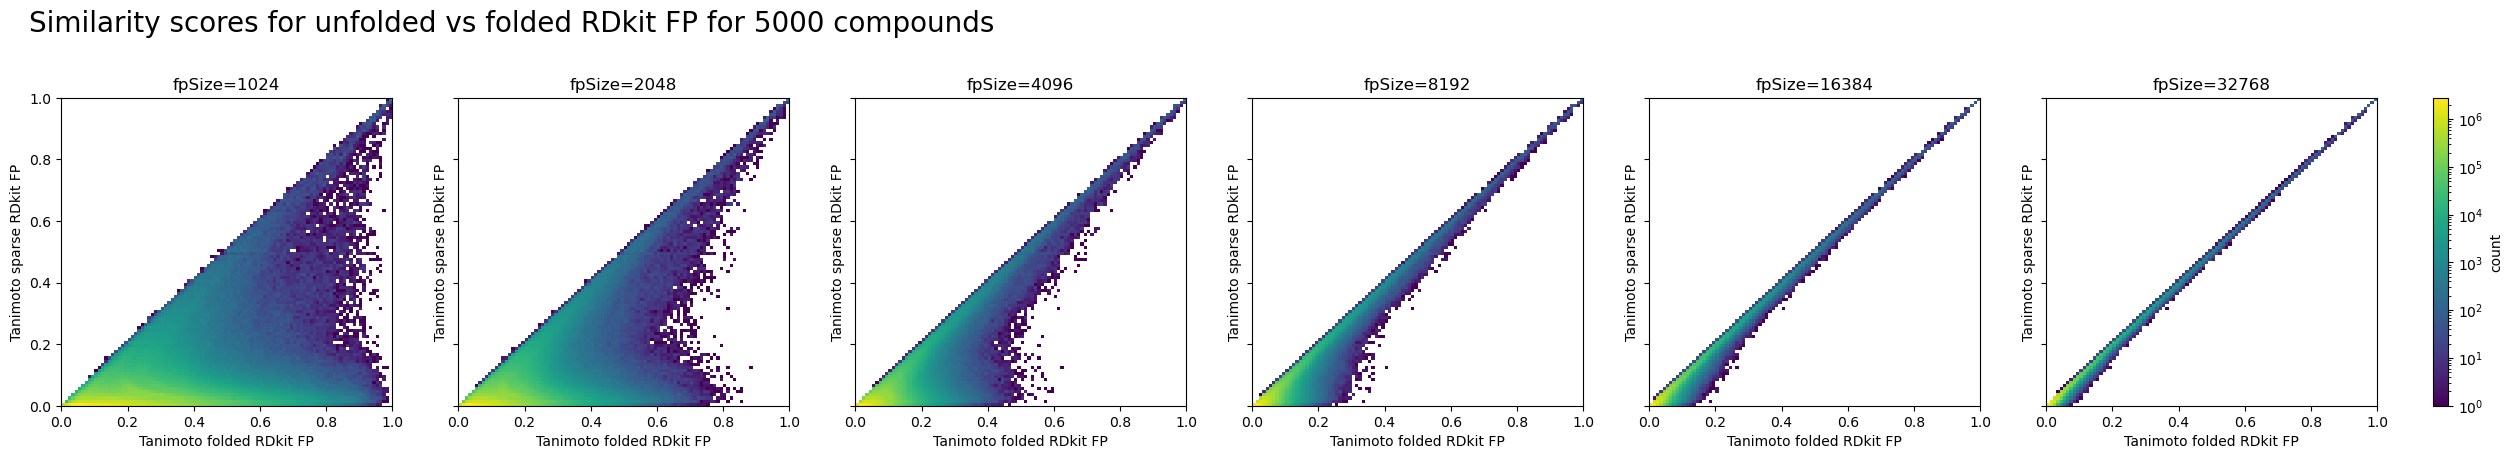

In [71]:
# Now for the rdFingerprintGenerator, that can be easily replaced by copy pasting the right 'Get...' in the code
# be aware the rdkit fps take very long to compute ~50 minutes

# define
df_sample = df.sample(n=5000, random_state=42)
mols = df_sample.Structure
n = len(mols)
sizes = [1024, 2048, 4096, 8192, 16384, 32768]
name='RDkit FP'

# fingerprints 
fingerprints = {size: [rdFingerprintGenerator.GetRDKitFPGenerator(fpSize=size).GetFingerprint(m) for m in mols] for size in sizes}
sparse_fp = [rdFingerprintGenerator.GetRDKitFPGenerator().GetSparseFingerprint(m) for m in mols]

# subplot grid
fig, axes = plt.subplots(1, len(sizes), figsize=(6*len(sizes), 4), sharex=True, sharey=True)

for ax, size in zip(axes, sizes):
    fp = fingerprints[size]
    counts = np.zeros((100, 100))

    # make the 2d historgram
    for i in tqdm(range(n), desc=f"Processing fpSize={size}", unit="mol"):
        sims_fold = DataStructs.BulkTanimotoSimilarity(fp[i], fp[i+1:])
        sims_sparse = DataStructs.BulkTanimotoSimilarity(sparse_fp[i], sparse_fp[i+1:])
        
        hist, _, _ = np.histogram2d(
            sims_fold, sims_sparse,
            bins=100, range=[[0,1],[0,1]]
        )
        counts += hist

    # mask zero-count bin
    counts_masked = np.ma.masked_where(counts == 0, counts)

    # subplot
    mesh = ax.pcolormesh(
        np.linspace(0,1,101),
        np.linspace(0,1,101),
        counts_masked.T,
        cmap="viridis",
        norm=LogNorm(vmin=1, vmax=counts.max())
    )
    ax.set_xlabel(f"Tanimoto folded {name}")
    ax.set_ylabel(f"Tanimoto sparse {name}")
    ax.set_title(f"fpSize={size}")

#one shared colorbar
fig.colorbar(mesh, ax=axes, label="count", pad=0.02)
fig.suptitle(f"Similarity scores for unfolded vs folded {name} for {n} compounds", fontsize=20, y=1.1, x=0.25)
plt.show()